In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

In [37]:
df = pd.read_csv("SampleSuperstore.csv")
df

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


Which shipping mode does the customer choose based on the products category and sum of the quantity?

In [24]:
df_shipmode = df[['Ship Mode','Category', 'Quantity']].groupby(['Ship Mode','Category']).sum('Quantity')
df_shipmode

Quantity
Ship Mode      Category                 
First Class    Furniture            1238
               Office Supplies      3372
               Technology           1083
Same Day       Furniture             453
               Office Supplies      1147
               Technology            360
Second Class   Furniture            1569
               Office Supplies      4480
               Technology           1374
Standard Class Furniture            4768
               Office Supplies     13907
               Technology           4122

<AxesSubplot:title={'center':'Ship Mode vs Sum of Quantity'}, xlabel='ship Mode with Category', ylabel='Sum of Quantity'>

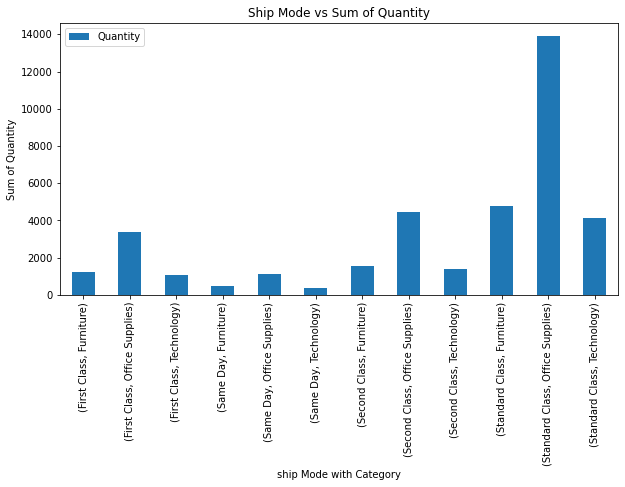

In [28]:
df_shipmode.plot(kind='bar', title='Ship Mode vs Sum of Quantity', ylabel="Sum of Quantity", xlabel="ship Mode with Category", figsize=(10,5))
#most customers choose standard mode for shipping while compared to other modes

Maximum number of Sales from which State?

In [32]:
state_sales_df= pd.pivot_table(data=df[['State','Sales']],index=["State"],values='Sales',aggfunc='max')
state_sales_df.sort_values(by='Sales',ascending=False).head(10)

,Sales
State,
Florida,22638.480
Indiana,17499.950
Washington,13999.960
New York,11199.968
Delaware,10499.970
Michigan,9892.740
Minnesota,9449.950
New Jersey,9099.930
Virginia,8749.950


<AxesSubplot:xlabel='State'>

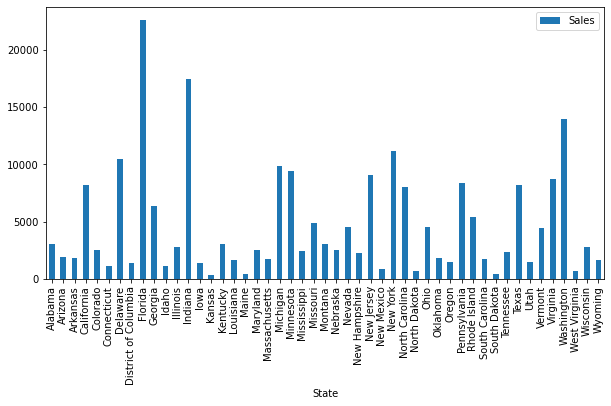

In [36]:
state_sales_df.plot(kind='bar',figsize=(10,5))
#Maximum Sales in Florida

From which State do we get maximum profit?

In [44]:
df_max_profit = pd.pivot_table(data=df[['State',"Profit"]], index=["State"], values = "Profit", aggfunc="max")
df_max_profit = df_max_profit.sort_values(by="Profit",ascending=False)

<AxesSubplot:xlabel='State'>

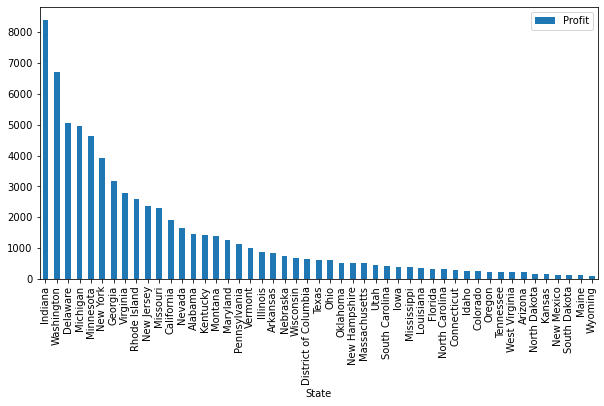

In [45]:
df_max_profit.plot(kind='bar',figsize=(10,5))

 Which Products are selling the most?

In [48]:
df_category_sales = pd.pivot_table(data=df[['Category','Sub-Category','Sales']],index=["Category","Sub-Category"], values="Sales", aggfunc="max").sort_values(by="Sales", ascending=False)

<AxesSubplot:xlabel='Category,Sub-Category'>

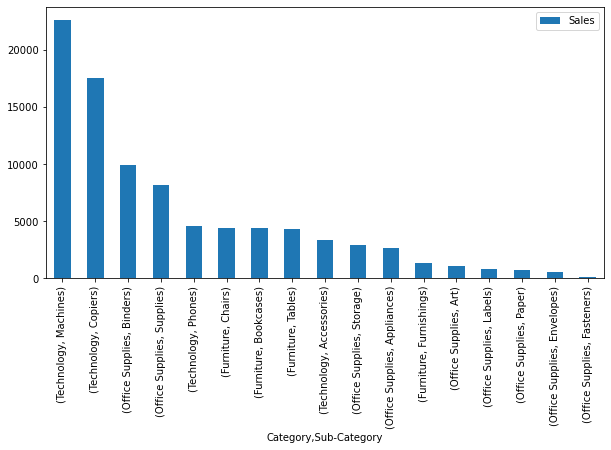

In [49]:
df_category_sales.plot(kind='bar',figsize=(10,5))

In [52]:
df_category_sales

Sales
Category        Sub-Category           
Technology      Machines      22638.480
                Copiers       17499.950
Office Supplies Binders        9892.740
                Supplies       8187.650
Technology      Phones         4548.810
Furniture       Chairs         4416.174
                Bookcases      4404.900
                Tables         4297.644
Technology      Accessories    3347.370
Office Supplies Storage        2934.330
                Appliances     2625.120
Furniture       Furnishings    1336.440
Office Supplies Art            1113.024
                Labels          786.480
                Paper           733.950
                Envelopes       604.656
                Fasteners        93.360

Which Products are purchased in more quantity?

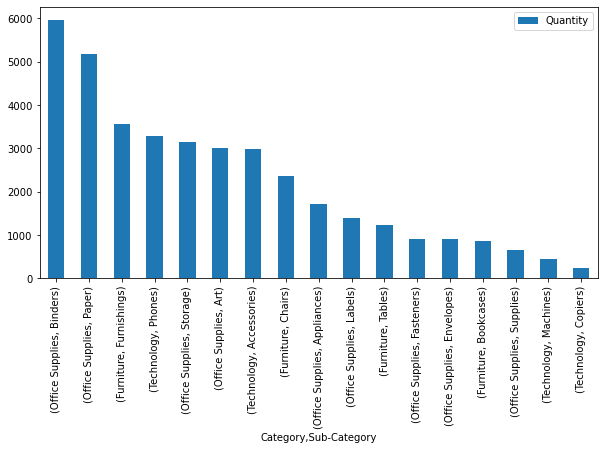

In [55]:
df_Cateegory_Quantity = pd.pivot_table(data=df[['Category','Sub-Category','Quantity']], index = ['Category','Sub-Category'], values = "Quantity", aggfunc='sum').sort_values(by="Quantity", ascending=False).plot(kind="bar",figsize=(10,5))

By selling which products we got the maximum profit?

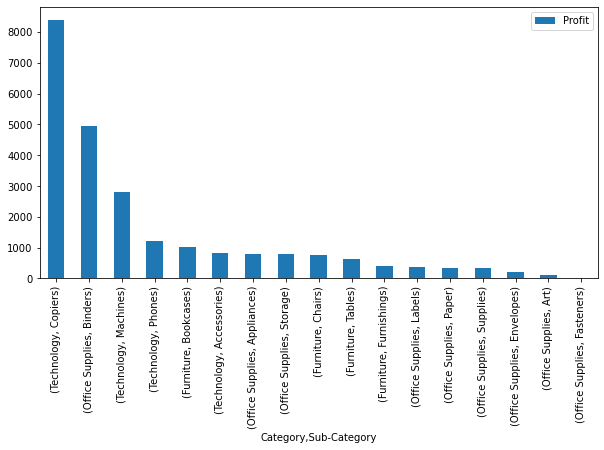

In [63]:
df_Category_Profit= pd.pivot_table(data = df[["Category","Sub-Category","Profit"]], index=['Category','Sub-Category'], values = "Profit", aggfunc='max').sort_values(by="Profit", ascending =False).plot(kind='bar',figsize=(10,5))